In [47]:
import pandas as pd

df = pd.read_csv("heart.csv")
print(df.shape)
print(df.head())
print(df.columns.tolist())


(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
target
1    165
0    138
Name: count, dtype: int64


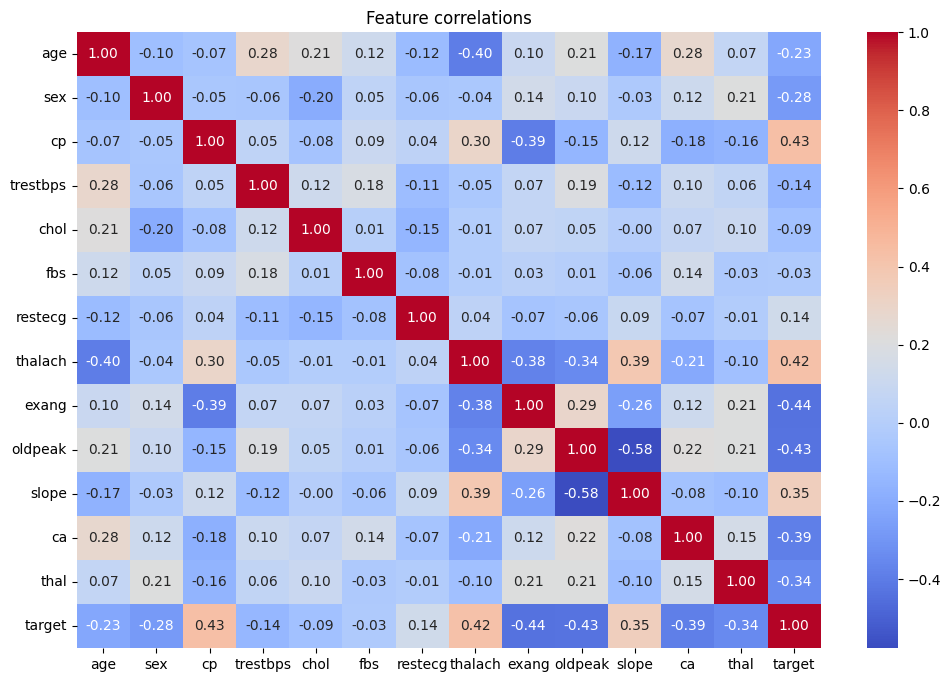

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("heart.csv")
print(df.dtypes)
print(df.isnull().sum())
print(df['target'].value_counts())

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlations")
plt.show()

In [49]:
from preprocess import load_and_preprocess_data

X_train, X_test, y_train, y_test = load_and_preprocess_data("heart.csv")

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n{name} | AUC: {auc:.3f}")
    print(classification_report(y_test, y_pred))


Logistic Regression | AUC: 0.869
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Random Forest | AUC: 0.909
              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61


Gradient Boosting | AUC: 0.880
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81 

Logistic Regression: AUC = 0.869
Random Forest: AUC = 0.909
Gradient Boosting: AUC = 0.880
SVM: AUC = 0.883

Best model: Random Forest


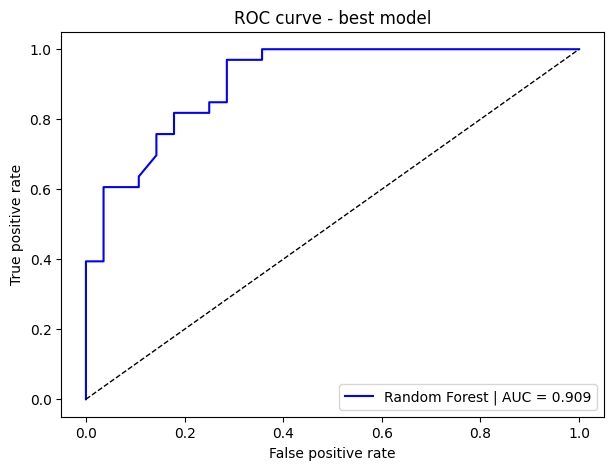

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    results[name] = (model, auc_score)
    print(f"{name}: AUC = {auc_score:.3f}")

best_name = max(results, key=lambda k: results[k][1])
best_model = results[best_name][0]
print(f"\nBest model: {best_name}")

#ROC curve for the best model
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_name} | AUC = {roc_auc:.3f}", color = "blue")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve - best model")
plt.legend()
plt.show()

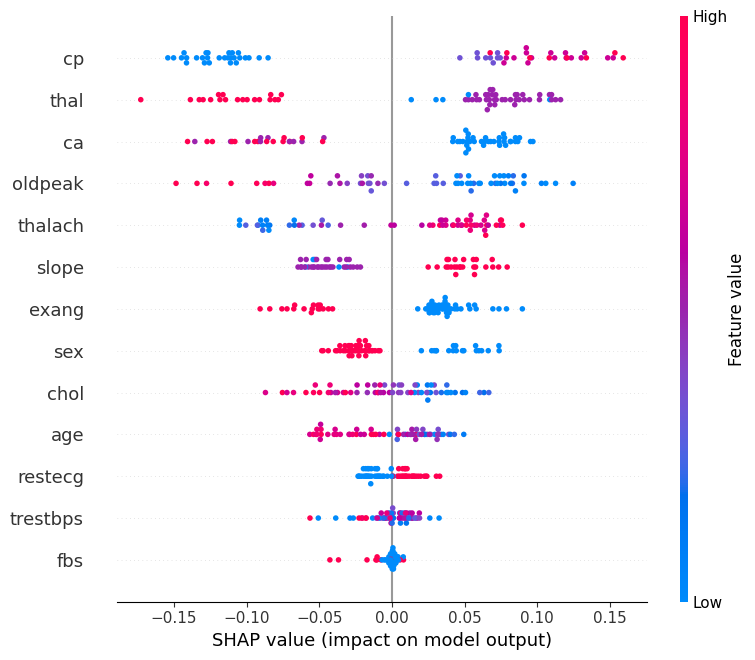

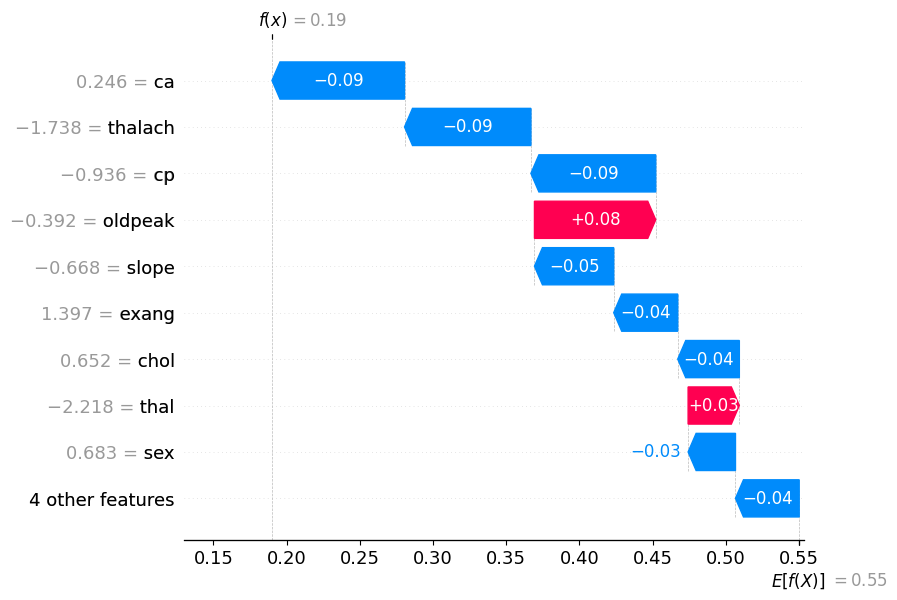

In [51]:
import shap
import pandas as pd
import numpy as np

shap.initjs() # required for force plot JS rendering

feature_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 
    'fbs', 'restecg', 'thalach', 'exang', 
    'oldpeak', 'slope', 'ca', 'thal'
]

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(models["Random Forest"].fit(X_train, y_train))
shap_values = explainer.shap_values(X_test)

# Feature names
if hasattr(X_train, "columns"):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"feature_{i}" for i in range(X_test.shape[1])]

X_test_df = pd.DataFrame(X_test, columns=feature_names)

# For binary Random Forest: shap_values is a list of 2 arrays, shape (n_samples, n_features)
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_to_plot = shap_values
    expected_value = explainer.expected_value[1]

# Summary plot
shap.summary_plot(shap_to_plot[:, :, 1], X_test_df)

# Force plot for single patient (row 0)
explanation = shap.Explanation(
    values=shap_to_plot[0, :, 1],
    base_values=expected_value,
    data=X_test_df.iloc[0].values,
    feature_names=feature_names
)

shap.plots.waterfall(explanation)